
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import get_scorer_names

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## 2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [ ]:
movie_metadata.info()
# For categorical variables
cat = movie_metadata.select_dtypes(include=['object']).columns
movie_metadata[cat] = movie_metadata[cat].astype('category')

<class 'pandas.core.frame.DataFrame'>
Index: 3755 entries, 0 to 5042
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_critic_for_reviews        3755 non-null   float64
 1   duration                      3755 non-null   float64
 2   director_facebook_likes       3755 non-null   float64
 3   actor_3_facebook_likes        3755 non-null   float64
 4   actor_1_facebook_likes        3755 non-null   float64
 5   gross                         3755 non-null   float64
 6   num_voted_users               3755 non-null   int64  
 7   cast_total_facebook_likes     3755 non-null   int64  
 8   facenumber_in_poster          3755 non-null   float64
 9   num_user_for_reviews          3755 non-null   float64
 10  budget                        3755 non-null   float64
 11  actor_2_facebook_likes        3755 non-null   float64
 12  imdb_score                    3755 non-null   float64
 13  aspect_r

In [4]:
#import the encoders
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [5]:
## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [6]:
## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [7]:
## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [8]:
## encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [9]:
## encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

In [10]:
# encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [11]:
# encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')

#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

In [12]:
# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 8.0 else "average" if x > 6.0 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

In [13]:
X = movie_metadata.drop('gross', axis=1)
y = movie_metadata['gross']

## 3 Check for missing variables and correct as needed.

In [ ]:
print(movie_metadata.isnull().sum())
movie_metadata = movie_metadata.dropna()
movie_metadata = movie_metadata.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'], axis=1)

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

In [27]:
# determine the range and variance of the target variable
print("Target variable range: ", y.min(), "to", y.max())
print("Target variable variance: ", y.var())

Target variable range:  162.0 to 760505847.0
Target variable variance:  4945253136156610.0


## 6 Split your data into test, tune, and train. (80/10/10)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test, train_size=0.50, random_state=49)

## 7 Create the kfold object for cross validation.

In [ ]:
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    #"max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

## 8 Create the scoring metric (several measures) you will use to evaluate your model and the max depth hyperparameter.

In [ ]:
print(get_scorer_names())  # find them
scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']

## 9 Build the regression tree object. 

In [ ]:
#Regressor model we will use
reg=DecisionTreeRegressor(random_state=30)

#Set up search for best decisiontreeregressor estimator based on r-sqaured and all the different folds...
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

#execute search on our trianing data
model = search.fit(X_train, y_train)

In [21]:
best= model.best_estimator_
print(best)

DecisionTreeRegressor(max_depth=5, random_state=30)


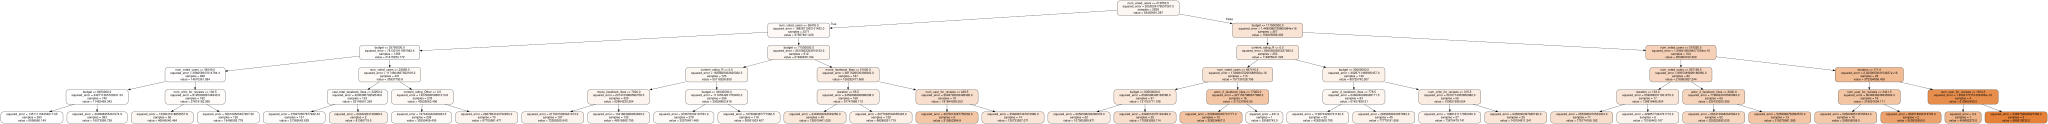

In [ ]:
import graphviz

dot_data = export_graphviz(best, out_file=None,
               feature_names=X.columns,  # feature names from dataset
               filled=True, 
               rounded=True) 
               
graph = graphviz.Source(dot_data)
graph #Pretty big, it is a continuous target afterall.

## 10 Fit the model to the training data.

In [ ]:
# best hyperparameters
print("Best Hyperparameters: ", model.best_params_)
# best score
print("Best Score: ", model.best_score_)

Best Hyperparameters:  {'max_depth': 5}
Best Score:  0.5221240540319537
Best Estimator:  DecisionTreeRegressor(max_depth=5, random_state=30)
Best Index:  4
Best Estimator Score:  0.5336853701199349


In [ ]:
model = 

## 10 Fit the model to the training data.

## 11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

## 12 Which variables appear to be contributing the most (variable importance)

## 13 Create a model object using the best model hyperparameter value from the trained regression tree.

## 14 Using the best model predict on the tune data and print out the results.

## 15 How does the model perform on the tune data as compared to the training data?

## 16 What five movies are predicted to have the lowest gross revenue from the tune set?

## 17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

## 18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

## 19 Use the best model to predict on the test data and print out the evaluation results.

## 20 Does the model perform well on the test data when compared to the training and tune data? Why or why not?

## 21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

## 22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.